In [ ]:
import pandas as pd
import os

# Define the file path using a raw string to handle Windows backslashes safely
file_path = r"/home/matias/Documents/Tesis/Vision-Aided-Beamformer/tests/dataset_out/Avance_1/exp_A.parquet"

# Verify if the file exists before attempting to load it
if os.path.exists(file_path):
    # Load the Parquet file into a Pandas DataFrame
    df_metrics = pd.read_parquet(file_path)

    # Filter out all rows where rt60 is 0.0 (anechoic conditions) and reset the index
    df_metrics = df_metrics[df_metrics['rt60'] > 0.0].reset_index(drop=True)

    # Identify and keep only metadata columns and metrics evaluated with the 'anechoic' reference
    suffixes_to_drop = ('_early', '_reverberant')
    cols_to_keep = [col for col in df_metrics.columns if not col.endswith(suffixes_to_drop)]
    df_metrics = df_metrics[cols_to_keep]

    # Strip the '_anechoic' suffix from the column names for cleaner plotting later
    df_metrics.columns = [col.replace('_anechoic', '') if col.endswith('_anechoic') else col for col in df_metrics.columns]

    print(f"Dataset successfully loaded and filtered (RT60 > 0.0 & only 'anechoic' metrics)! Shape: {df_metrics.shape}\n")

    # Display the first few rows to confirm data integrity
    display(df_metrics.head())

else:
    print(f"Error: File not found at the specified path:\n{file_path}")
    print("Please check your current working directory using 'import os; print(os.getcwd())'.")

Dataset successfully loaded and filtered (RT60 > 0.0 & only 'anechoic' metrics)! Shape: (576, 90)



,processor,rt60,M,N_interferences,mismatch_pos,isir_db,mismatch_gain,mismatch_phase,use_wpe,error_angle_deg,...,Delta_dtln_post_SAR,Delta_tot_pipeline_SAR,Delta_tot_SINR,Delta_wpe_SINR,Delta_bf_SINR,dtln_alone_SINR,dtln_post_SINR,Delta_dtln_alone_SINR,Delta_dtln_post_SINR,Delta_tot_pipeline_SINR
0,DS-SV,0.3,4,1,0.0,0,0,0,False,0.0,...,2.199743,2.435791,1.185094,0.0,1.185094,14.357674,17.195686,14.813544,16.466462,17.651556
1,MVDR (VAD Oráculo),0.3,4,1,0.0,0,0,0,False,0.0,...,3.166219,2.659495,1.626503,0.0,1.626503,14.357674,18.865867,14.813544,17.695234,19.321737
2,MVDR-CS (VAD Oráculo),0.3,4,1,0.0,0,0,0,False,0.0,...,0.441627,-0.520268,11.009019,0.0,11.009019,14.357674,15.643707,14.813544,5.090557,16.099577
3,MVDR-SV (SPP),0.3,4,1,0.0,0,0,0,False,0.0,...,1.607181,-0.161300,0.387279,0.0,0.387279,14.357674,17.741825,14.813544,17.810416,18.197695
4,MPDR-SV,0.3,4,1,0.0,0,0,0,False,0.0,...,2.747453,1.889247,1.079391,0.0,1.079391,14.357674,17.878014,14.813544,17.254493,18.333884


/tmp/ipykernel_46506/2240337150.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_46506/2240337150.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_46506/2240337150.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_46506/2240337150.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


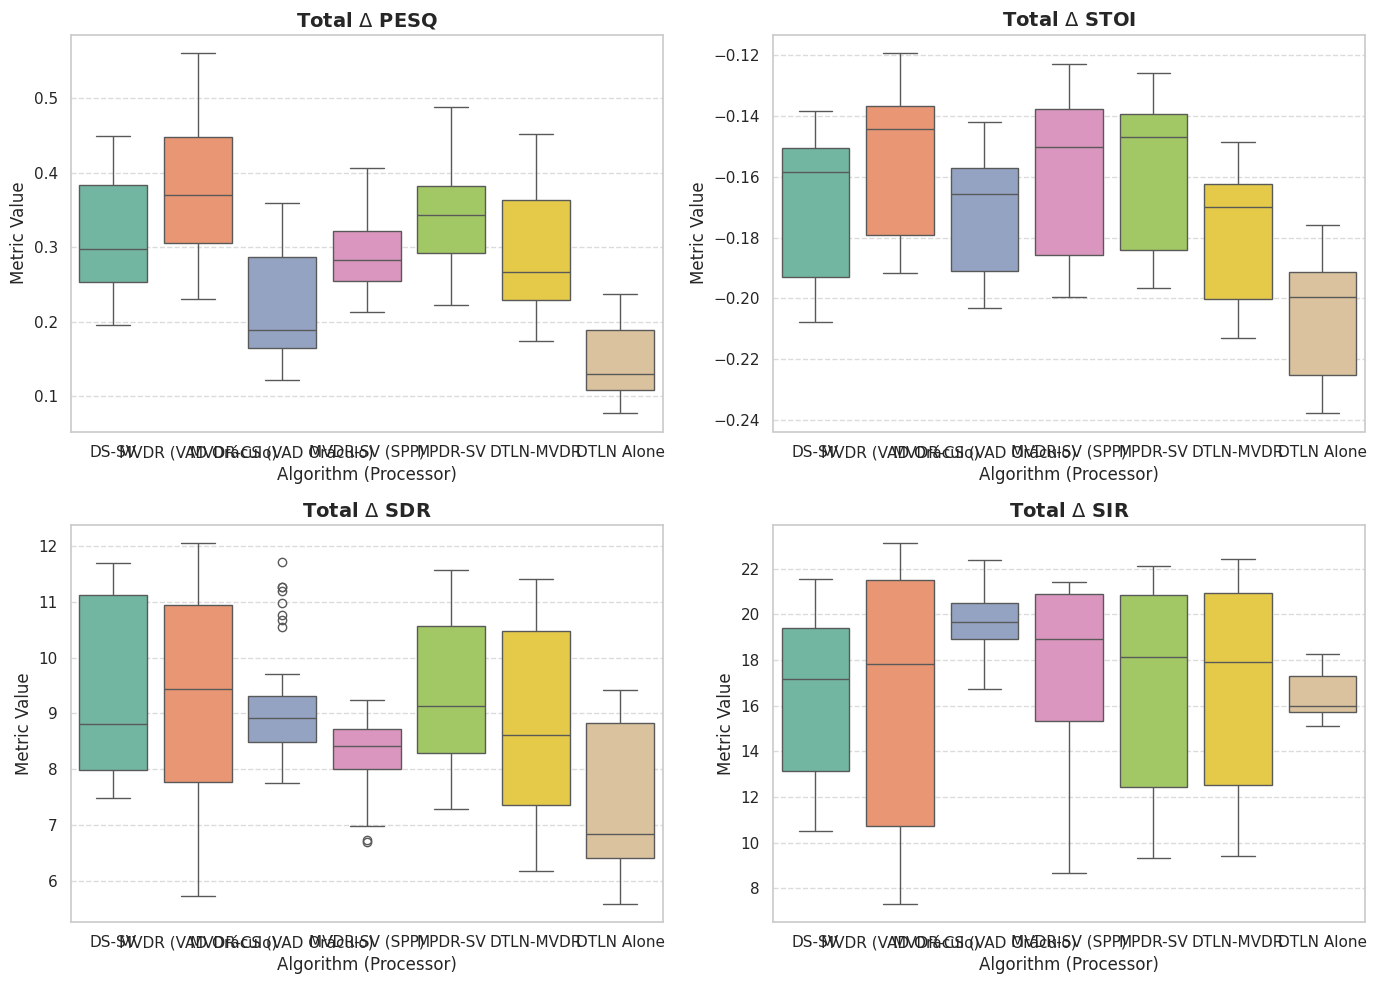

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SDR', 'SIR']

# We will build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer + DTLN results
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        col_name = f'Delta_tot_pipeline_{metric}'
        if col_name in df_proc.columns:
            for val in df_proc[col_name].dropna():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': val
                })

# 2. Extract DTLN Alone results
# DTLN alone is computed per acoustic scene, not per processor.
# To avoid duplicating the exact same DTLN alone values for every processor
# evaluated in the same scene, we just grab them from the first processor's rows.
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_dtln_alone = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        col_name = f'Delta_dtln_alone_{metric}'
        if col_name in df_dtln_alone.columns:
            for val in df_dtln_alone[col_name].dropna():
                plot_data.append({
                    'Algorithm': 'DTLN Alone',
                    'Metric': metric,
                    'Value': val
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):

    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot with Algorithms on the X-axis and metric values on the Y-axis
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        ax=axes[i],
        palette='Set2'
    )

    # Format titles and labels for clarity
    axes[i].set_title(f'Total $\Delta$ {metric}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Metric Value', fontsize=12)
    axes[i].set_xlabel('Algorithm (Processor)', fontsize=12)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust the layout so plots do not overlap
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define the root directory to save all generated figures for the thesis
FIGURES_DIR = r"/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Define the Okabe-Ito color palette for colorblind accessibility
# Colors: Orange, Sky Blue, Bluish Green, Yellow, Blue, Vermilion, Reddish Purple, Black
OKABE_ITO_PALETTE = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442",
    "#0072B2", "#D55E00", "#CC79A7", "#000000"
]

def set_thesis_plot_style():
    """
    Applies global formatting rules for Matplotlib and Seaborn.
    Integrates Okabe-Ito colors and sizes appropriate for an A4 LaTeX document.
    """
    # Set the general Seaborn style and apply the new palette
    sns.set_theme(style="whitegrid", context="paper")
    sns.set_palette(sns.color_palette(OKABE_ITO_PALETTE))

    # Configure Matplotlib parameters
    plt.rcParams.update({
        # Typography: Sans-serif is recommended for charts for better readability
        # If you want to strictly match LaTeX text, change "sans-serif" to "serif"
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

        # Font sizes coordinated with an 11pt main text in LaTeX
        "font.size": 11,                 # Base font size (matches document)
        "axes.titlesize": 11,            # Subplot title size
        "axes.labelsize": 10,            # Axis labels slightly smaller than main text
        "xtick.labelsize": 9,            # Tick labels (max 2 points smaller)
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "legend.title_fontsize": 10,

        # Apply Okabe-Ito to base Matplotlib cycle (for non-Seaborn plots)
        "axes.prop_cycle": plt.cycler('color', OKABE_ITO_PALETTE),

        # Dimensions matching A4 paper with standard 2.5 cm margins
        # Text width is ~160mm (6.3 inches). Height uses the golden ratio (~3.89 inches).
        "figure.figsize": (6.3, 3.89),

        # High resolution outputs
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",         # Removes unnecessary white space around edges

        # Line and marker weights
        "lines.linewidth": 1.5,          # Slightly thicker for better visibility
        "lines.markersize": 5
    })

/tmp/ipykernel_46506/549493177.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_46506/549493177.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_46506/549493177.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_46506/549493177.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


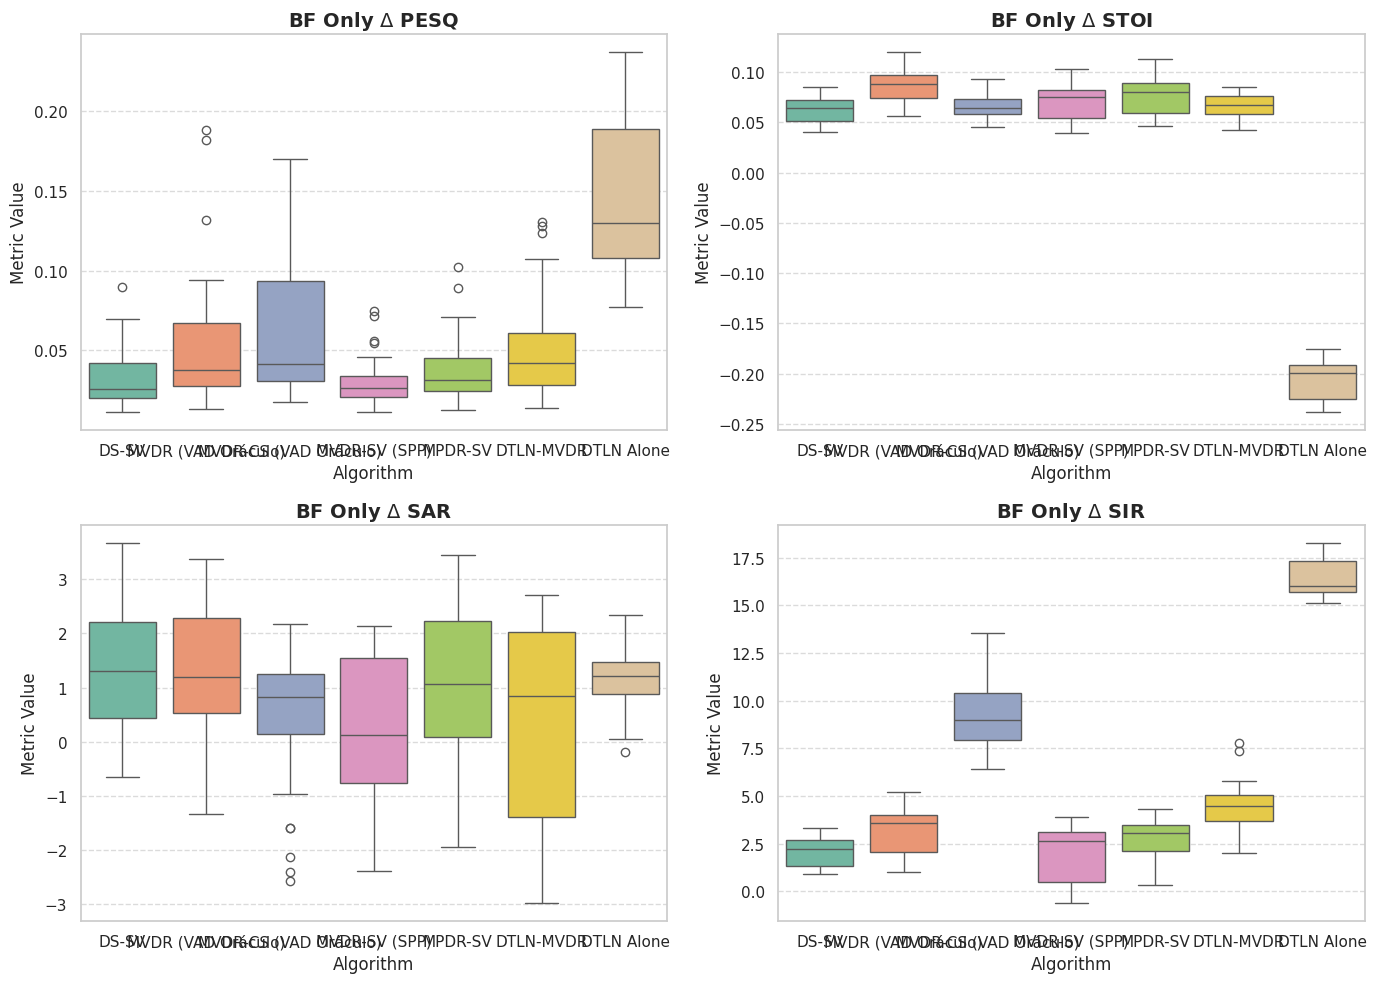

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the base metrics to plot
base_metrics = ['PESQ', 'STOI', 'SAR', 'SIR']

# We will build a new structured DataFrame specifically formatted for Seaborn
plot_data = []

# 1. Extract Beamformer-only results (No DTLN post-processing)
for proc in df_filtered['processor'].unique():
    df_proc = df_filtered[df_filtered['processor'] == proc]
    for metric in base_metrics:
        # We use 'Delta_tot_' to get the performance of the Beamformer alone compared to the baseline
        col_name = f'Delta_tot_{metric}'
        if col_name in df_proc.columns:
            for val in df_proc[col_name].dropna():
                plot_data.append({
                    'Algorithm': proc,
                    'Metric': metric,
                    'Value': val
                })

# 2. Extract DTLN Alone results
# We extract this only from the first processor's rows to avoid duplicating
# the same DTLN values for the same acoustic scene.
if len(df_filtered['processor'].unique()) > 0:
    first_proc = df_filtered['processor'].unique()[0]
    df_dtln_alone = df_filtered[df_filtered['processor'] == first_proc]

    for metric in base_metrics:
        col_name = f'Delta_dtln_alone_{metric}'
        if col_name in df_dtln_alone.columns:
            for val in df_dtln_alone[col_name].dropna():
                plot_data.append({
                    'Algorithm': 'DTLN Alone',
                    'Metric': metric,
                    'Value': val
                })

# Convert the collected data into a Pandas DataFrame
df_plot = pd.DataFrame(plot_data)

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Loop through the base metrics and create a boxplot for each
for i, metric in enumerate(base_metrics):

    # Filter the unified data for the current metric
    df_subset = df_plot[df_plot['Metric'] == metric]

    # Create the boxplot with Algorithms on the X-axis and metric values on the Y-axis
    sns.boxplot(
        data=df_subset,
        x='Algorithm',
        y='Value',
        ax=axes[i],
        palette='Set2'
    )

    # Format titles and labels for clarity
    axes[i].set_title(f'BF Only $\Delta$ {metric}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Metric Value', fontsize=12)
    axes[i].set_xlabel('Algorithm', fontsize=12)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust the layout so plots do not overlap
plt.tight_layout()

# Display the plot
plt.show()

Figure saved successfully at:
/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado/mics_no_wpe.pdf


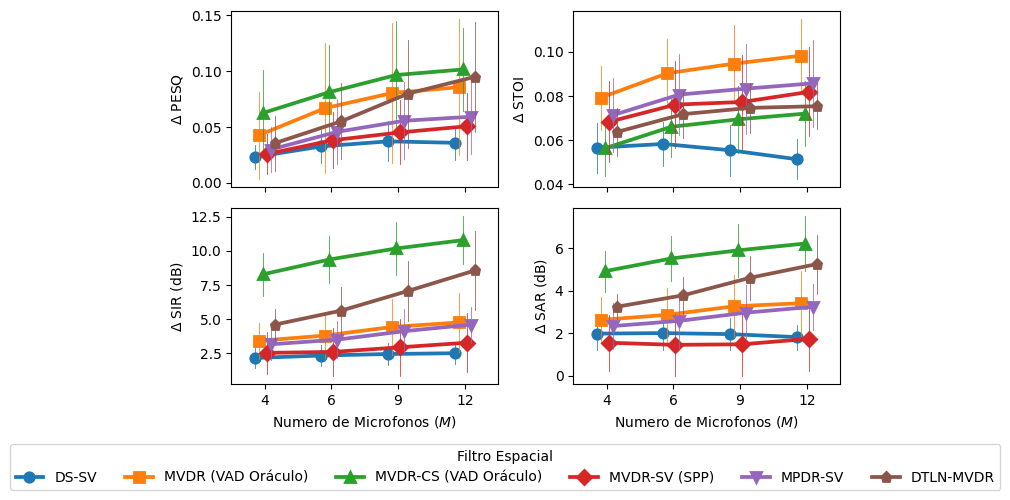

In [ ]:
# ==============================================================================
# BLOCK 2: GENERATE BEAMFORMER PERFORMANCE PLOT (WITHOUT WPE) - COMPACT Y-LABELS
# ==============================================================================

def plot_beamformer_deltas_vs_m_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR)
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis
    to maximize plotting area.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == True].copy()

    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SDR': r'$\Delta$ SAR (dB)'
    }

    # Create a 2x2 subplot grid
    # Height adjusted back to 5.0 since we removed the titles
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()

    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]

    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]

        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot,
            x='M',
            y=metric_col,
            hue='processor',
            dodge=0.3,
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9},
            capsize=0,
            ax=ax
        )

        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Numero de Microfonos ($M$)')
        ax.set_ylabel(y_label)

        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()

    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()

    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels,
        title='Filtro Espacial',
        loc='center',
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),
        frameon=True,
        framealpha=0.8
    )

    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "mics_no_wpe.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")

    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_m_compact(df_metrics)

/tmp/ipykernel_46506/2474613835.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_46506/2474613835.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_46506/2474613835.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_46506/2474613835.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


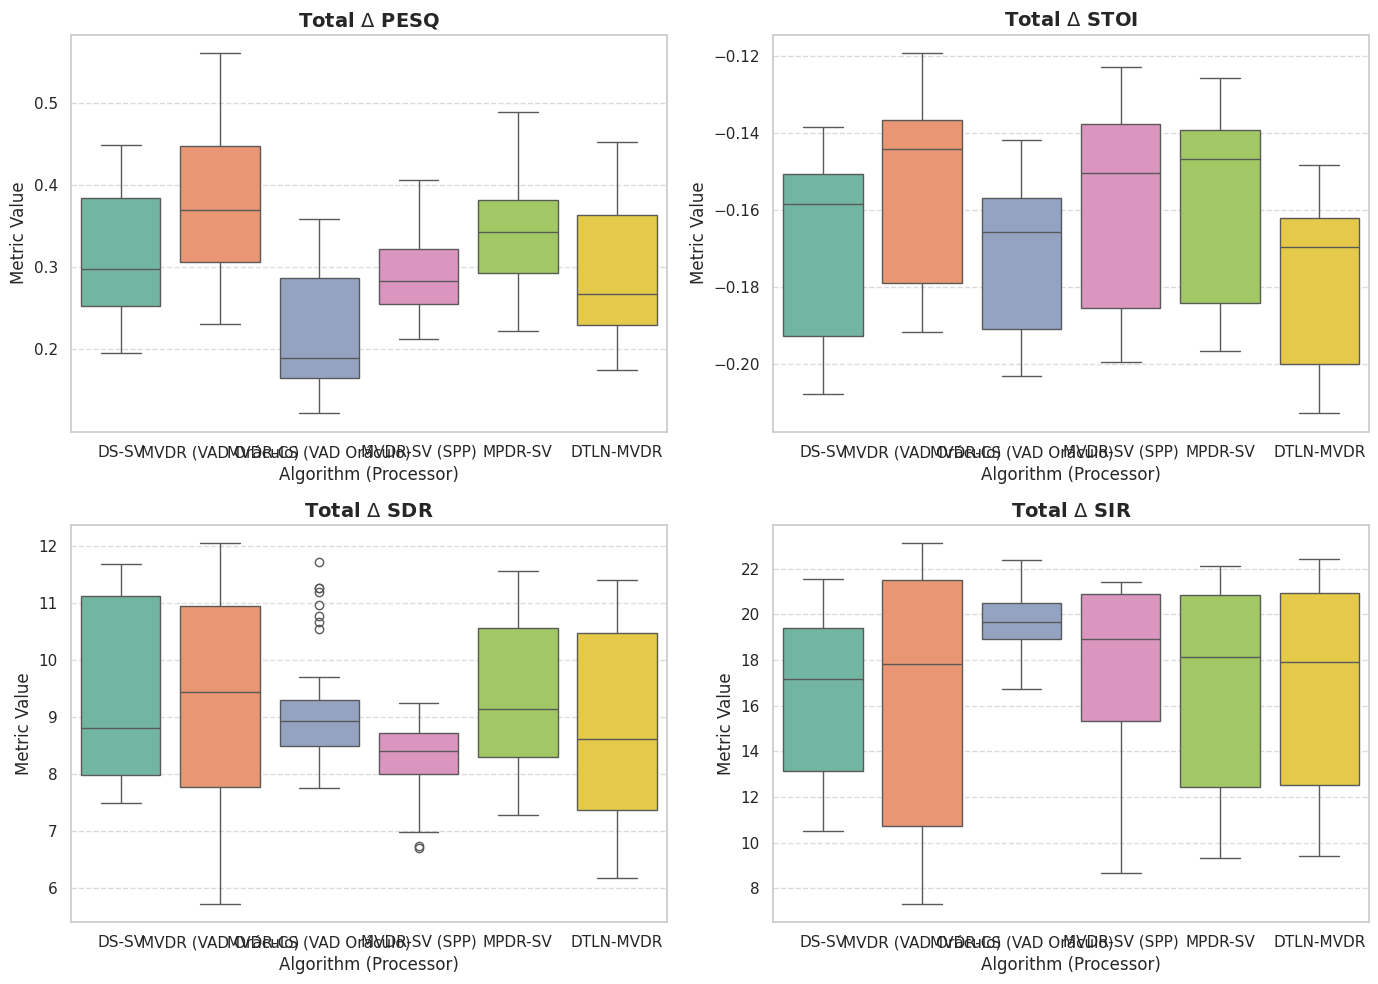

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the dataset: keep only the results where WPE is disabled
df_filtered = df_metrics[df_metrics['use_wpe'] == False].copy()

# Define the 4 metrics to plot.
# We use 'Delta_tot_pipeline_' to show the total improvement (Beamformer + DTLN).
# Note: If you want to plot absolute values instead of deltas, change these to 'dtln_post_PESQ', etc.
metrics_to_plot = [
    'Delta_tot_pipeline_PESQ',
    'Delta_tot_pipeline_STOI',
    'Delta_tot_pipeline_SDR',
    'Delta_tot_pipeline_SIR'
]

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Loop through the selected metrics and create a boxplot for each
for i, metric in enumerate(metrics_to_plot):

    # Create the boxplot with processors on the X-axis and metric values on the Y-axis
    sns.boxplot(
        data=df_filtered,
        x='processor',
        y=metric,
        ax=axes[i],
        palette='Set2'
    )

    # Format titles and labels for clarity
    # Remove the prefix for a cleaner title
    clean_title = metric.replace('Delta_tot_pipeline_', 'Total $\Delta$ ')
    axes[i].set_title(clean_title, fontsize=14, fontweight='bold')

    axes[i].set_ylabel('Metric Value', fontsize=12)
    axes[i].set_xlabel('Algorithm (Processor)', fontsize=12)

    # Add horizontal gridlines to easily read the values
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust the layout so plots do not overlap
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# ==============================================================================
# BLOCK 3: GENERATE BEAMFORMER PERFORMANCE PLOT VS INTERFERENCES (WITHOUT WPE)
# ==============================================================================

def plot_beamformer_deltas_vs_interferences_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR)
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates performance against the Numero de Interferencias I.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == False].copy()

    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }

    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()

    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]

    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]

        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot,
            x='N_interferences',   # Changed X-axis variable to Numero de Interferencias I
            y=metric_col,
            hue='processor',
            dodge=0.3,
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9},
            capsize=0,
            ax=ax
        )
        # -------------------------------------------------------------
        # INVERT Y-AXIS SPECIFICALLY FOR SAR
        # -------------------------------------------------------------


        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Numero de Interferencias I') # Updated label
        ax.set_ylabel(y_label)

        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        if 'SAR' in metric_col:
            ax.invert_yaxis()


    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()

    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()

    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels,
        title='Spatial Filter',
        loc='center',
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),
        frameon=True,
        framealpha=0.8
    )

    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "deltas_vs_interferences.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")

    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_interferences_compact(df_metrics)

NameError: name 'df_metrics' is not defined

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\t60_sin_wpe.pdf


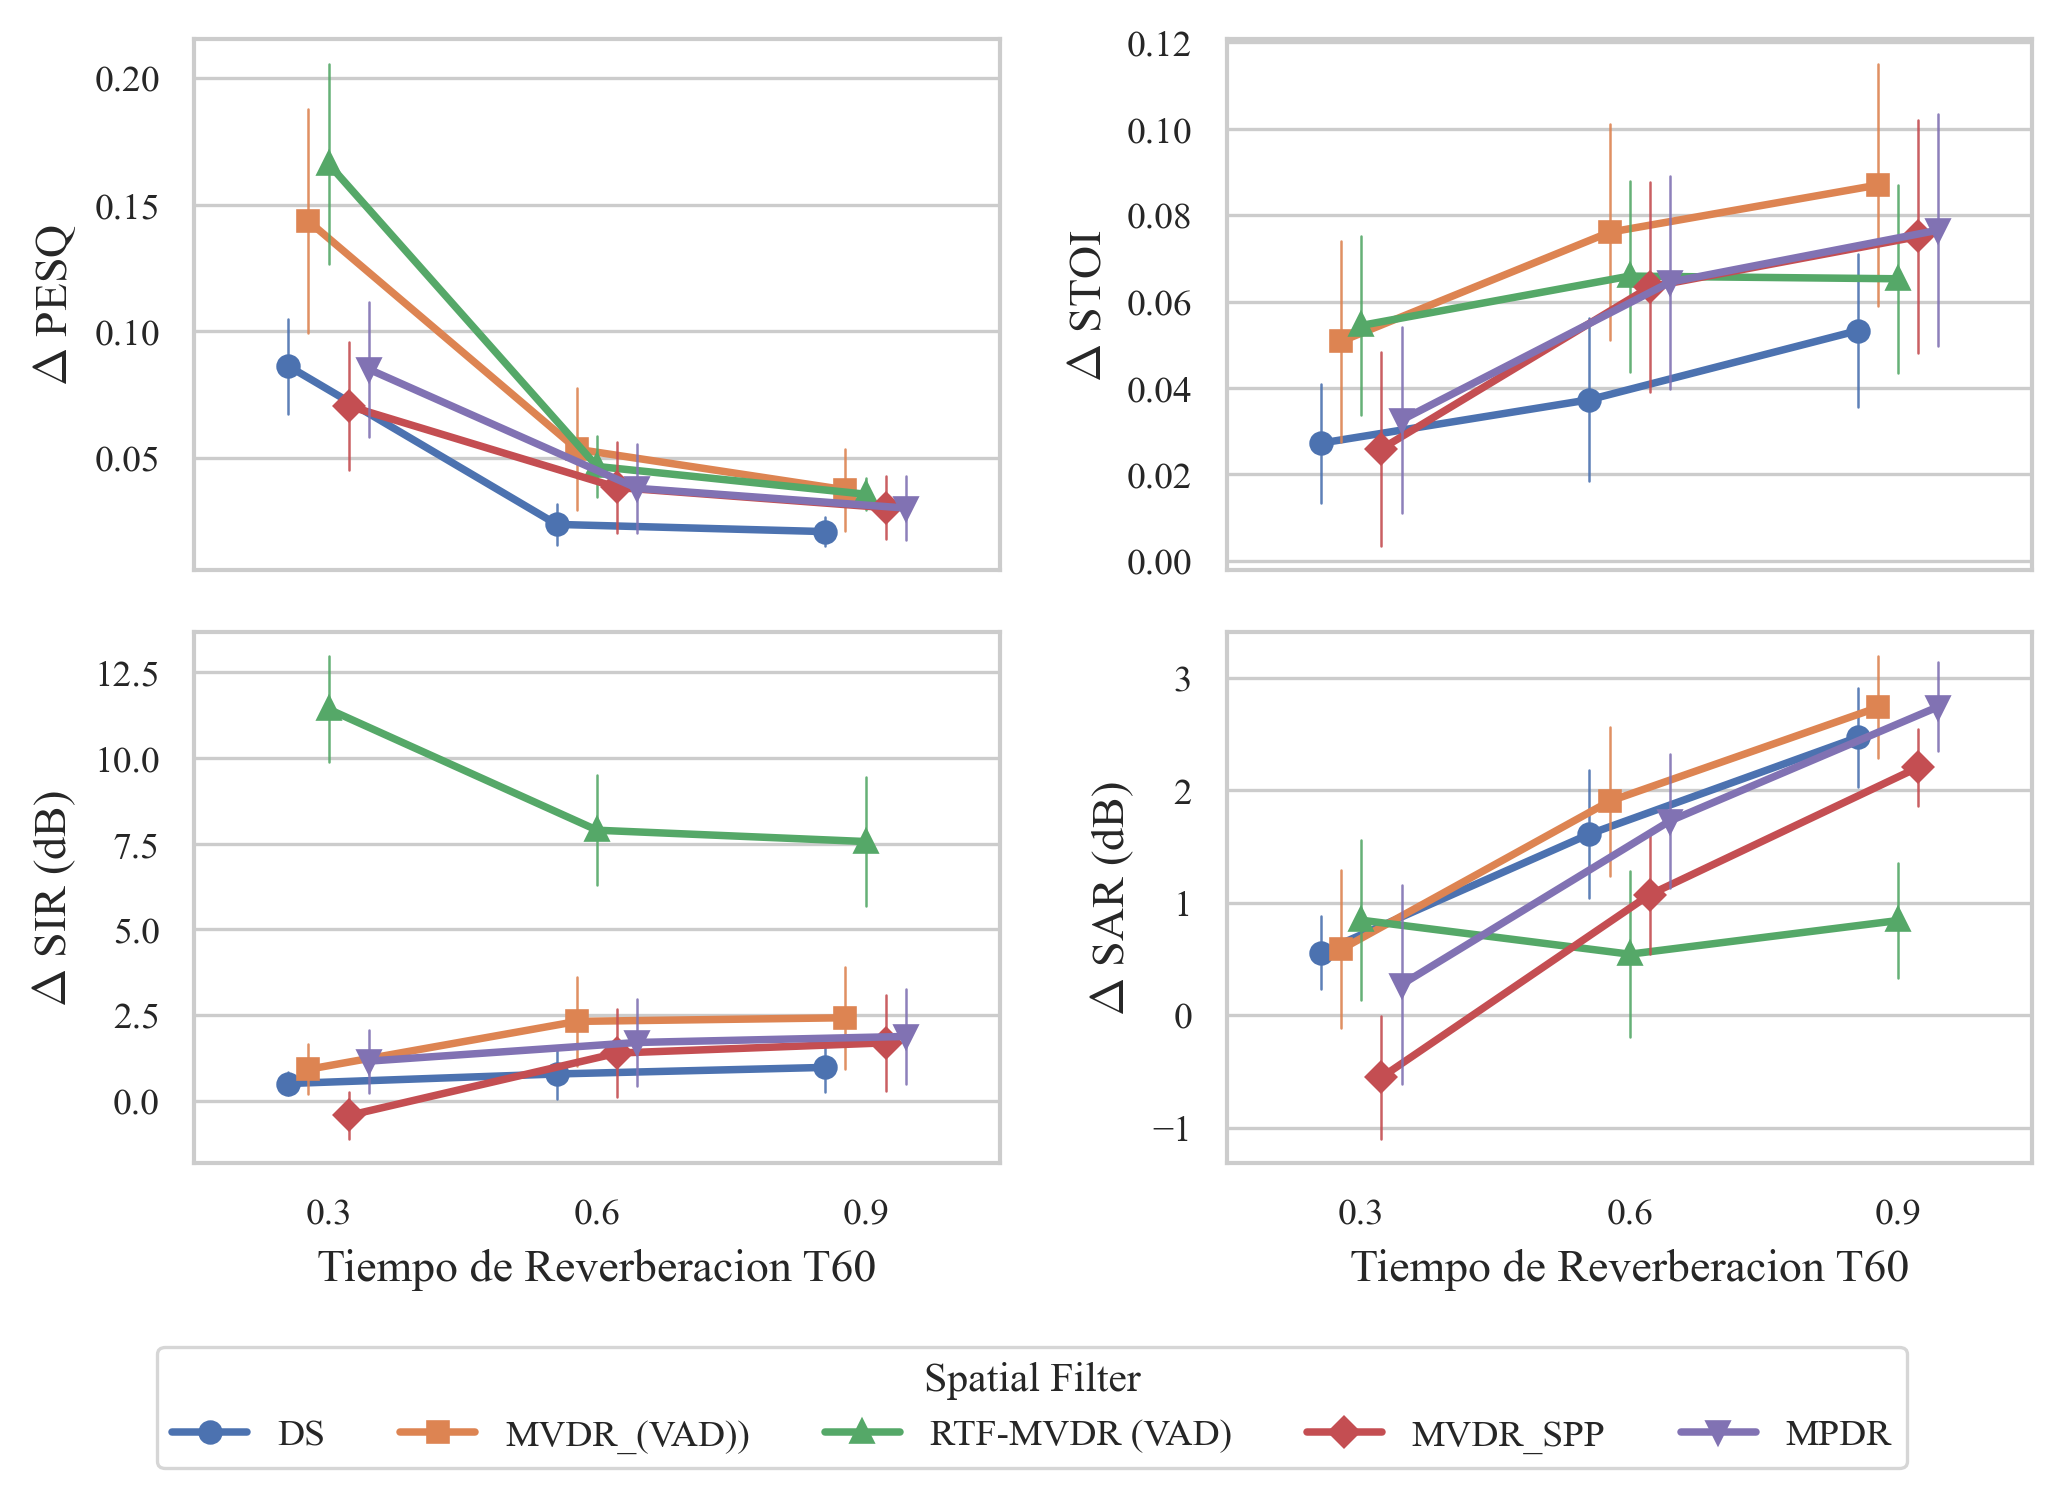

In [ ]:
# ==============================================================================
# BLOCK 3: GENERATE BEAMFORMER PERFORMANCE PLOT VS INTERFERENCES (WITHOUT WPE)
# ==============================================================================

def plot_beamformer_deltas_vs_interferences_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR)
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates performance against the Numero de Interferencias I.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == False].copy()

    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }

    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2,figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()

    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]

    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]

        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot,
            x='rt60',   # Changed X-axis variable to Numero de Interferencias I
            y=metric_col,
            hue='processor',
            dodge=0.3,
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9},
            capsize=0,
            ax=ax
        )

        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Tiempo de Reverberacion T60') # Updated label
        ax.set_ylabel(y_label)

        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()

    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()

    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels,
        title='Spatial Filter',
        loc='center',
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),
        frameon=True,
        framealpha=0.8
    )

    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "t60_sin_wpe.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")

    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_interferences_compact(df_metrics)

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\t60_con_wpe.pdf


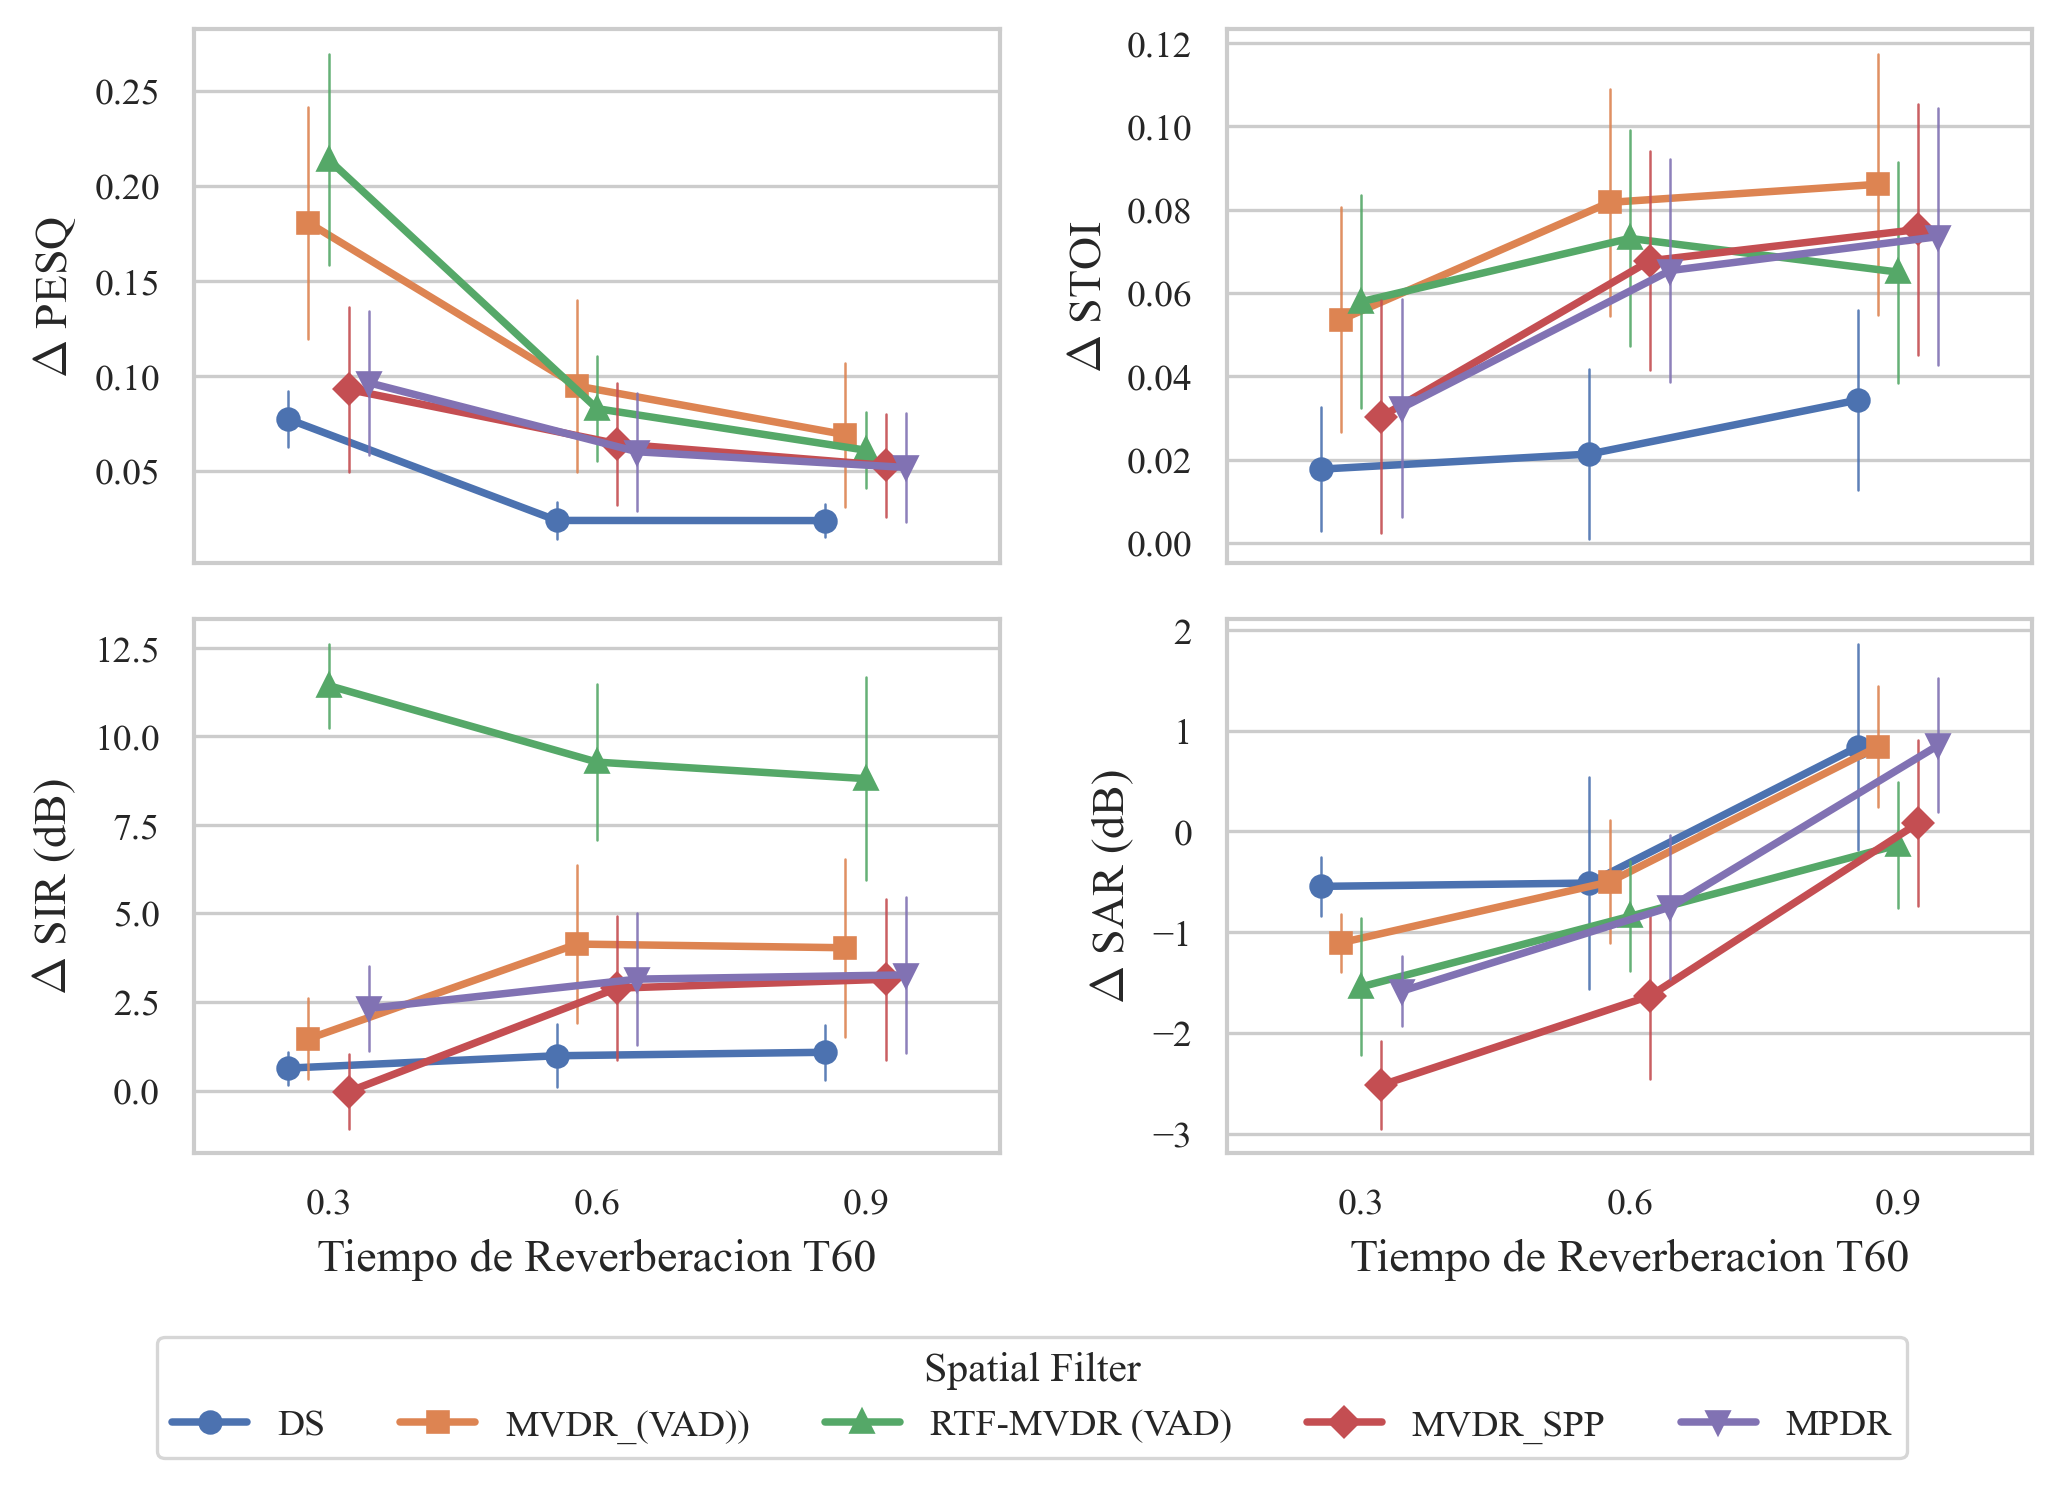

In [ ]:
# ==============================================================================
# BLOCK 3: GENERATE BEAMFORMER PERFORMANCE PLOT VS INTERFERENCES (WITHOUT WPE)
# ==============================================================================

def plot_beamformer_deltas_vs_interferences_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR)
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates performance against the Numero de Interferencias I.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == True].copy()

    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }

    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()

    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]

    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]

        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot,
            x='rt60',   # Changed X-axis variable to Numero de Interferencias I
            y=metric_col,
            hue='processor',
            dodge=0.3,
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9},
            capsize=0,
            ax=ax
        )

        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Tiempo de Reverberacion T60') # Updated label
        ax.set_ylabel(y_label)

        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()

    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()

    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels,
        title='Spatial Filter',
        loc='center',
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),
        frameon=True,
        framealpha=0.8
    )

    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "t60_con_wpe.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")

    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_interferences_compact(df_metrics)

In [ ]:
# ==============================================================================
# BLOCK 4: GENERATE WPE COMPARISON PLOT (AVERAGED ACROSS ALL PROCESSORS)
# ==============================================================================

def plot_wpe_comparison_vs_rt60(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR).
    Averages the performance of all spatial filters and compares the results
    with and without WPE pre-processing over different reverberation times.
    """
    # We need the full dataset (no WPE filter applied here)
    df_plot = df.copy()

    # Create a new column with readable labels for the legend
    df_plot['Condición WPE'] = df_plot['use_wpe'].map({True: 'Con WPE', False: 'Sin WPE'})

    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }

    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, pdffigsize=(7, 4.5), sharex=True)
    axes = axes.flatten()

    # Only two markers needed now
    markers = ['o', 's']

    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]

        # Pointplot will automatically calculate the mean of all processors
        sns.pointplot(
            data=df_plot,
            x='rt60',                 # Evaluated against reverberation time
            y=metric_col,
            hue='Condición WPE',      # Hue changed to WPE status
            dodge=0.1,                # Reduced dodge since there are only 2 lines
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9},
            capsize=0,
            ax=ax
        )

        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Tiempo de Reverberación ($RT_{60}$)')
        ax.set_ylabel(y_label)

        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()

    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()

    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels,
        title='Pre-procesamiento',
        loc='center',
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=2,                      # Only two columns for the legend
        frameon=True,
        framealpha=0.8
    )

    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "deltas_vs_rt_wpe_sin_con.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")

    # Display the plot
    plt.show()

# Execute the plotting function (pass the complete dataframe)
plot_wpe_comparison_vs_rt60(df_metrics)

AttributeError: Figure.set() got an unexpected keyword argument 'pdffigsize'